# Setup

In [1]:
from pathlib import Path
import ast
import json
import yaml
import numpy as np
import pandas as pd
from thesis_assyrian_relief.utils.inspection import (
    plot_relief_views,
    plot_query_and_retrieved_reliefs,
    plot_query_image_retrieval_row
)
from sklearn.metrics.pairwise import cosine_similarity
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)




In [2]:
def embedding_matrix(df: pd.DataFrame) -> np.ndarray:
    """
    Supports either:
    1. one column named 'embedding' containing arrays/lists
    2. multiple numeric columns named emb_0, emb_1, ...
    3. multiple numeric columns named embedding_0, embedding_1, ...
    """
    if "embedding" in df.columns:
        return np.vstack(df["embedding"].apply(lambda x: np.asarray(x, dtype=np.float32)).to_numpy())

    emb_cols = [c for c in df.columns if c.startswith("emb_")]
    if not emb_cols:
        emb_cols = [c for c in df.columns if c.startswith("embedding_")]

    if not emb_cols:
        raise ValueError(
            "Could not find embedding columns. Expected either 'embedding', "
            "'emb_*', or 'embedding_*' columns."
        )

    emb_cols = sorted(
        emb_cols,
        key=lambda c: int(c.split("_")[-1]) if c.split("_")[-1].isdigit() else c,
    )

    return df[emb_cols].to_numpy(dtype=np.float32)


def image_filename_from_row(row: pd.Series) -> str:
    if "image_filename" in row.index and pd.notna(row["image_filename"]):
        return str(row["image_filename"])

    if "image_path" in row.index and pd.notna(row["image_path"]):
        return Path(str(row["image_path"])).name

    suffix = str(row["suffix"])
    if not suffix.startswith("."):
        suffix = "." + suffix

    return f"{row['relief_id']}-{int(row['view_index'])}{suffix}"


def compute_image_retrieval(
    query_df: pd.DataFrame,
    gallery_df: pd.DataFrame,
    k: int = 5,
) -> pd.DataFrame:
    q_emb = embedding_matrix(query_df)
    g_emb = embedding_matrix(gallery_df)

    sims = cosine_similarity(q_emb, g_emb)

    rows = []

    for qi in range(len(query_df)):
        q = query_df.iloc[qi]
        order = np.argsort(-sims[qi])[:k]

        row = {
            "query_image_filename": image_filename_from_row(q),
            "query_image_path": q.get("image_path", None),
            "query_relief_id": q.get("relief_id", q.get("Relief_ID", None)),
            "query_authority": q.get("authority", q.get("Authority", None)),
            "query_view_index": q.get("view_index", None),
        }

        topk_filenames = []
        topk_paths = []
        topk_reliefs = []
        topk_labels = []
        topk_sims = []

        for rank, gi in enumerate(order, start=1):
            g = gallery_df.iloc[gi]

            g_filename = image_filename_from_row(g)
            g_path = g.get("image_path", None)
            g_relief = g.get("relief_id", g.get("Relief_ID", None))
            g_auth = g.get("authority", g.get("Authority", None))
            sim = float(sims[qi, gi])

            row[f"top{rank}_image_filename"] = g_filename
            row[f"top{rank}_image_path"] = g_path
            row[f"top{rank}_relief_id"] = g_relief
            row[f"top{rank}_authority"] = g_auth
            row[f"top{rank}_similarity"] = sim

            topk_filenames.append(g_filename)
            topk_paths.append(g_path)
            topk_reliefs.append(g_relief)
            topk_labels.append(g_auth)
            topk_sims.append(sim)

        row["topk_image_filenames"] = topk_filenames
        row["topk_image_paths"] = topk_paths
        row["topk_reliefs"] = topk_reliefs
        row["topk_labels"] = topk_labels
        row["topk_sims"] = topk_sims

        rows.append(row)

    return pd.DataFrame(rows)

In [3]:
OUTPUT_ROOT = Path("../outputs/only_3_classes/")
# IMAGE_LEVEL_CSV = "../data/splits/image_level_dataset_v2.csv"
# IMAGE_ROOT = "/mnt/c/Users/chend/Desktop/My_Files/Thesis/Dataset/dataset_v2"
# FAILURES_CSV = OUTPUT_ROOT/"retrieval"/"test_failures.csv"
# FAILURES_CSV = "../outputs/retrieval/test_failures_v2.csv"

CONFIG_PATH = OUTPUT_ROOT/"style_dinov2_runtime.yaml"
EVAL_SPLIT = "test"

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

IMAGE_LEVEL_CSV = Path(cfg["data"]["csv_path"])
IMAGE_ROOT = Path(cfg["data"]["image_root"])
FILENAME_SEP = cfg["data"].get("filename_sep", "-")

TRAIN_IMAGE_EMB_PATH = OUTPUT_ROOT /"eval"/"train_image_embeddings.pkl"
EVAL_IMAGE_EMB_PATH = OUTPUT_ROOT /"eval"/f"{EVAL_SPLIT}_image_embeddings.pkl"

IMAGE_PREDS_CSV = OUTPUT_ROOT /"eval"/f"{EVAL_SPLIT}_image_predictions.csv"
RELIEF_RETRIEVAL_CSV = OUTPUT_ROOT /"eval"/f"{EVAL_SPLIT}_retrieval.csv"
IMAGE_RETRIEVAL_CSV = OUTPUT_ROOT /"eval"/f"{EVAL_SPLIT}_image_retrieval.csv"
FAILURES_CSV = OUTPUT_ROOT /"retrieval"/f"{EVAL_SPLIT}_failures.csv"

# show the failure table compactly

In [4]:
df_failures = pd.read_csv(FAILURES_CSV)
cols = [
    "query_relief_id",
    "query_authority",
    "topk_reliefs",
    "topk_labels",
    "topk_sims",
    "top1_correct",
    "top3_hit",
    "top5_hit",
]

df_failures[cols]

,query_relief_id,query_authority,topk_reliefs,topk_labels,topk_sims,top1_correct,top3_hit,top5_hit
0,BM 118914,Ashurbanipal,"['BM 124537', 'BRK 55.152', 'BM 124585', 'BRK 55.150', 'MET 17.190.2081']","['Ashurnasirpal II', 'Ashurnasirpal II', 'Ashurnasirpal II', 'Ashurnasirpal II', 'Ashurnasirpal II']","[0.9155673384666443, 0.9123305678367615, 0.9120202660560608, 0.9112675189971924, 0.9029120802879333]",False,False,False
1,BM 124920,Ashurbanipal,"['BRK 55.152', 'BM 124537', 'BM 124585', 'BM 124569', 'MET 17.190.2081']","['Ashurnasirpal II', 'Ashurnasirpal II', 'Ashurnasirpal II', 'Ashurnasirpal II', 'Ashurnasirpal II']","[0.9132602214813232, 0.9122043251991272, 0.9058823585510254, 0.904171347618103, 0.897318959236145]",False,False,False
2,MET 32.143.3,Ashurnasirpal II,"['BM 124793', 'BM 124919', 'BM 124801', 'BM 124886', 'BM 124890']","['Ashurbanipal', 'Ashurbanipal', 'Ashurbanipal', 'Ashurbanipal', 'Ashurbanipal']","[0.9864145517349243, 0.9859776496887207, 0.9852813482284546, 0.984585165977478, 0.9817520380020142]",False,False,False


# Image Level Inspection

In [5]:
train_img_emb_df = pd.read_pickle(TRAIN_IMAGE_EMB_PATH)
eval_img_emb_df = pd.read_pickle(EVAL_IMAGE_EMB_PATH)

print("train image embeddings:", train_img_emb_df.shape)
print("eval image embeddings:", eval_img_emb_df.shape)
print(train_img_emb_df.columns.tolist())

image_retrieval_df = compute_image_retrieval(
    query_df=eval_img_emb_df,
    gallery_df=train_img_emb_df,
    k=5,
)

image_retrieval_df.to_csv(IMAGE_RETRIEVAL_CSV, index=False)
print("Saved:", IMAGE_RETRIEVAL_CSV)

image_retrieval_df.head()

train image embeddings: (440, 5)
eval image embeddings: (62, 5)
['relief_id', 'authority', 'label', 'image_path', 'embedding']
Saved: ../outputs/only_3_classes/eval/test_image_retrieval.csv


,query_image_filename,query_image_path,query_relief_id,query_authority,query_view_index,top1_image_filename,top1_image_path,top1_relief_id,top1_authority,top1_similarity,top2_image_filename,top2_image_path,top2_relief_id,top2_authority,top2_similarity,top3_image_filename,top3_image_path,top3_relief_id,top3_authority,top3_similarity,top4_image_filename,top4_image_path,top4_relief_id,top4_authority,top4_similarity,top5_image_filename,top5_image_path,top5_relief_id,top5_authority,top5_similarity,topk_image_filenames,topk_image_paths,topk_reliefs,topk_labels,topk_sims
0,AO 19863-1.jpg,/mnt/c/Users/chend/Desktop/My_Files/Thesis/Dataset/dataset_v2/AO 19863-1.jpg,AO 19863,Sargon II,None,AO 1434-1.jpg,/mnt/c/Users/chend/Desktop/My_Files/Thesis/Dataset/dataset_v2/AO 1434-1.jpg,AO 1434,Sargon II,0.990613,AO 19865-1.jpg,/mnt/c/Users/chend/Desktop/My_Files/Thesis/Dataset/dataset_v2/AO 19865-1.jpg,AO 19865,Sargon II,0.989988,AO 19883-1.jpg,/mnt/c/Users/chend/Desktop/My_Files/Thesis/Dataset/dataset_v2/AO 19883-1.jpg,AO 19883,Sargon II,0.989706,BM 118828-5.jpg,/mnt/c/Users/chend/Desktop/My_Files/Thesis/Dataset/dataset_v2/BM 118828-5.jpg,BM 118828,Sargon II,0.987632,AO 19864-1.jpg,/mnt/c/Users/chend/Desktop/My_Files/Thesis/Dataset/dataset_v2/AO 19864-1.jpg,AO 19864,Sargon II,0.987575,"[AO 1434-1.jpg, AO 19865-1.jpg, AO 19883-1.jpg, BM 118828-5.jpg, AO 19864-1.jpg]","[/mnt/c/Users/chend/Desktop/My_Files/Thesis/Dataset/dataset_v2/AO 1434-1.jpg, /mnt/c/Users/chend/Desktop/My_Files/Thesis/Dataset/dataset_v2/AO 19865-1.jpg, /mnt/c/Users/chend/Desktop/My_Files/Thesis/Dataset/dataset_v2/AO 19883-1.jpg, /mnt/c/Users/chend/Desktop/My_Files/Thesis/Dataset/dataset_v2/BM 118828-5.jpg, /mnt/c/Users/chend/Desktop/My_Files/Thesis/Dataset/dataset_v2/AO 19864-1.jpg]","[AO 1434, AO 19865, AO 19883, BM 118828, AO 19864]","[Sargon II, Sargon II, Sargon II, Sargon II, Sargon II]","[0.9906134605407715, 0.9899877905845642, 0.9897061586380005, 0.9876316785812378, 0.9875754117965698]"
1,AO 19863-2.jpg,/mnt/c/Users/chend/Desktop/My_Files/Thesis/Dataset/dataset_v2/AO 19863-2.jpg,AO 19863,Sargon II,None,AO 1434-1.jpg,/mnt/c/Users/chend/Desktop/My_Files/Thesis/Dataset/dataset_v2/AO 1434-1.jpg,AO 1434,Sargon II,0.994322,BM 118818-1.jpg,/mnt/c/Users/chend/Desktop/My_Files/Thesis/Dataset/dataset_v2/BM 118818-1.jpg,BM 118818,Sargon II,0.991480,BM 118828-5.jpg,/mnt/c/Users/chend/Desktop/My_Files/Thesis/Dataset/dataset_v2/BM 118828-5.jpg,BM 118828,Sargon II,0.990942,AO 19864-1.jpg,/mnt/c/Users/chend/Desktop/My_Files/Thesis/Dataset/dataset_v2/AO 19864-1.jpg,AO 19864,Sargon II,0.990135,BM 118827-3.jpg,/mnt/c/Users/chend/Desktop/My_Files/Thesis/Dataset/dataset_v2/BM 118827-3.jpg,BM 118827,Sargon II,0.989467,"[AO 1434-1.jpg, BM 118818-1.jpg, BM 118828-5.jpg, AO 19864-1.jpg, BM 118827-3.jpg]","[/mnt/c/Users/chend/Desktop/My_Files/Thesis/Dataset/dataset_v2/AO 1434-1.jpg, /mnt/c/Users/chend/Desktop/My_Files/Thesis/Dataset/dataset_v2/BM 118818-1.jpg, /mnt/c/Users/chend/Desktop/My_Files/Thesis/Dataset/dataset_v2/BM 118828-5.jpg, /mnt/c/Users/chend/Desktop/My_Files/Thesis/Dataset/dataset_v2/AO 19864-1.jpg, /mnt/c/Users/chend/Desktop/My_Files/Thesis/Dataset/dataset_v2/BM 118827-3.jpg]","[AO 1434, BM 118818, BM 118828, AO 19864, BM 118827]","[Sargon II, Sargon II, Sargon II, Sargon II, Sargon II]","[0.9943222999572754, 0.991479754447937, 0.9909423589706421, 0.9901350140571594, 0.989466667175293]"
2,AO 19863-3.jpg,/mnt/c/Users/chend/Desktop/My_Files/Thesis/Dataset/dataset_v2/AO 19863-3.jpg,AO 19863,Sargon II,None,AO 1434-1.jpg,/mnt/c/Users/chend/Desktop/My_Files/Thesis/Dataset/dataset_v2/AO 1434-1.jpg,AO 1434,Sargon II,0.966360,AO 19867-1.jpg,/mnt/c/Users/chend/Desktop/My_Files/Thesis/Dataset/dataset_v2/AO 19867-1.jpg,AO 19867,Sargon II,0.964817,BM 118818-1.jpg,/mnt/c/Users/chend/Desktop/My_Files/Thesis/Dataset/dataset_v2/BM 118818-1.jpg,BM 118818,Sargon II,0.963045,AO 19896-1.jpg,/mnt/c/Users/chend/Desktop/My_Files/Thesis/Dataset/dataset_v2/AO 19896-1.jpg,AO 19896,Sargon II,0.958910,AO 19

In [ ]:
TARGET_RELIEF_ID = "BM 124920"

bm_img_retrieval = image_retrieval_df[
    image_retrieval_df["query_relief_id"] == TARGET_RELIEF_ID
].copy()

bm_img_retrieval[
    [
        "query_image_filename",
        "query_authority",
        "top1_image_filename",
        "top1_relief_id",
        "top1_authority",
        "top1_similarity",
        "top2_image_filename",
        "top2_relief_id",
        "top2_authority",
        "top2_similarity",
        "top3_image_filename",
        "top3_relief_id",
        "top3_authority",
        "top3_similarity",
    ]
]


for _, row in bm_img_retrieval.iterrows():
    fig = plot_query_image_retrieval_row(
        retrieval_row=row,
        image_root=IMAGE_ROOT,
        k=5,
        figsize_scale=4.0,
        show=True,
    )

In [ ]:
image_preds_df = pd.read_csv(IMAGE_PREDS_CSV)

bm_preds = image_preds_df[
    image_preds_df["relief_id"] == TARGET_RELIEF_ID
].copy()

bm_summary = bm_preds.merge(
    bm_img_retrieval,
    left_on="image_filename",
    right_on="query_image_filename",
    how="left",
)

bm_summary[
    [
        "image_filename",
        "true_authority",
        "pred_authority",
        "confidence",
        "prob_Ashurbanipal",
        "prob_Ashurnasirpal_II",
        "prob_Sargon_II",
        "top1_image_filename",
        "top1_relief_id",
        "top1_authority",
        "top1_similarity",
    ]
].sort_values("image_filename")

# inspect one failure by row index

In [4]:
row_idx = 1  # change this manually

row = df_failures.iloc[row_idx]

query_relief_id = row["query_relief_id"]
query_authority = row["query_authority"]

topk_reliefs = ast.literal_eval(row["topk_reliefs"]) if isinstance(row["topk_reliefs"], str) else row["topk_reliefs"]
topk_labels = ast.literal_eval(row["topk_labels"]) if isinstance(row["topk_labels"], str) else row["topk_labels"]
topk_sims = ast.literal_eval(row["topk_sims"]) if isinstance(row["topk_sims"], str) else row["topk_sims"]

print("Query relief:", query_relief_id)
print("Query authority:", query_authority)
print()

for i, (rid, lab, sim) in enumerate(zip(topk_reliefs, topk_labels, topk_sims), start=1):
    print(f"Rank {i}: {rid} | {lab} | sim={sim:.4f}")

Query relief: BM 124920
Query authority: Ashurbanipal

Rank 1: BRK 55.152 | Ashurnasirpal II | sim=0.9133
Rank 2: BM 124537 | Ashurnasirpal II | sim=0.9122
Rank 3: BM 124585 | Ashurnasirpal II | sim=0.9059
Rank 4: BM 124569 | Ashurnasirpal II | sim=0.9042
Rank 5: MET 17.190.2081 | Ashurnasirpal II | sim=0.8973


# show query + top retrieved reliefs

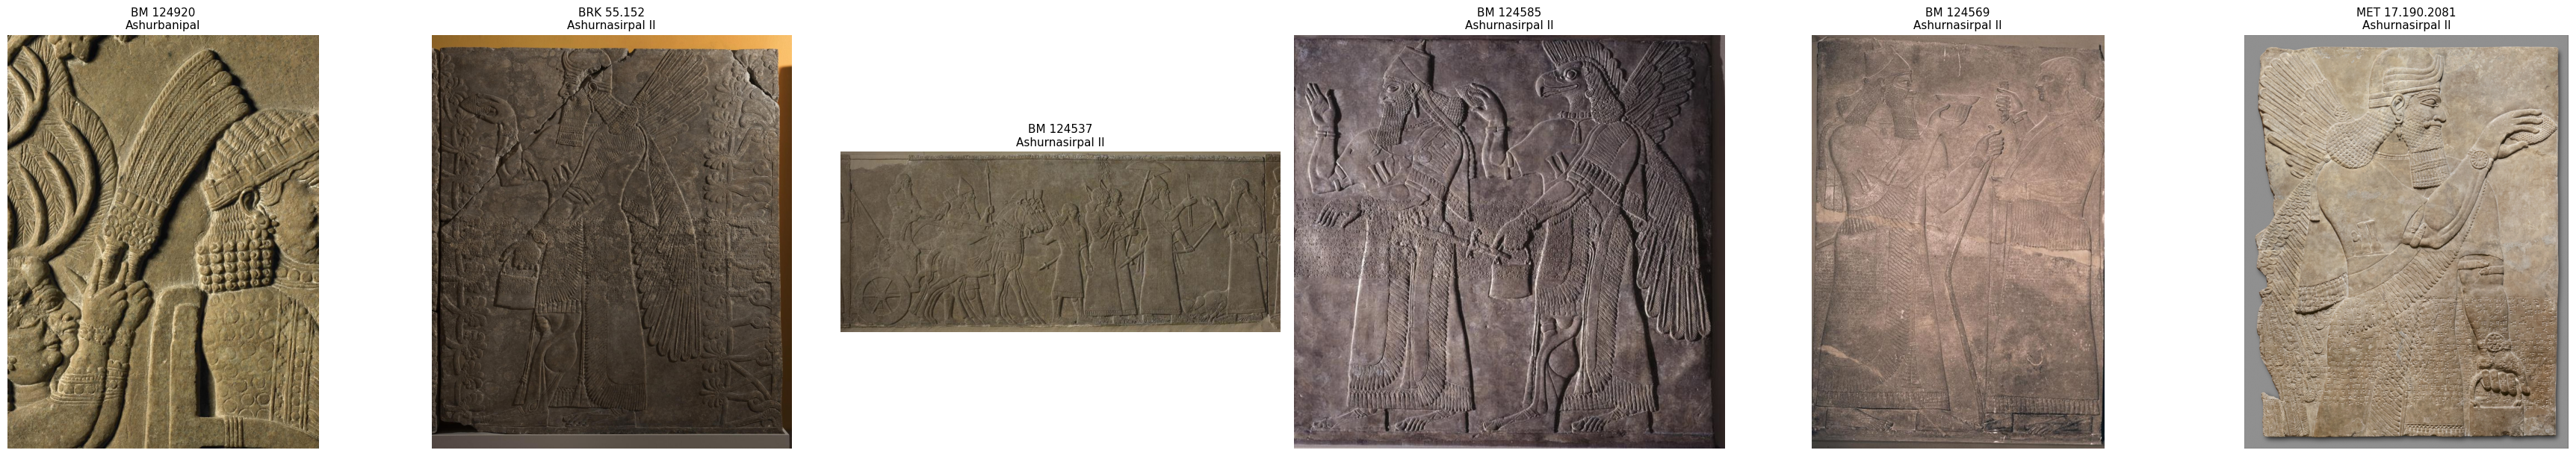

In [8]:
plot_query_and_retrieved_reliefs(
    image_level_csv=IMAGE_LEVEL_CSV,
    image_root=IMAGE_ROOT,
    query_relief_id=query_relief_id,
    retrieved_relief_ids=topk_reliefs[:5],   # first 3 retrieved neighbors
);

# show all views of the query relief

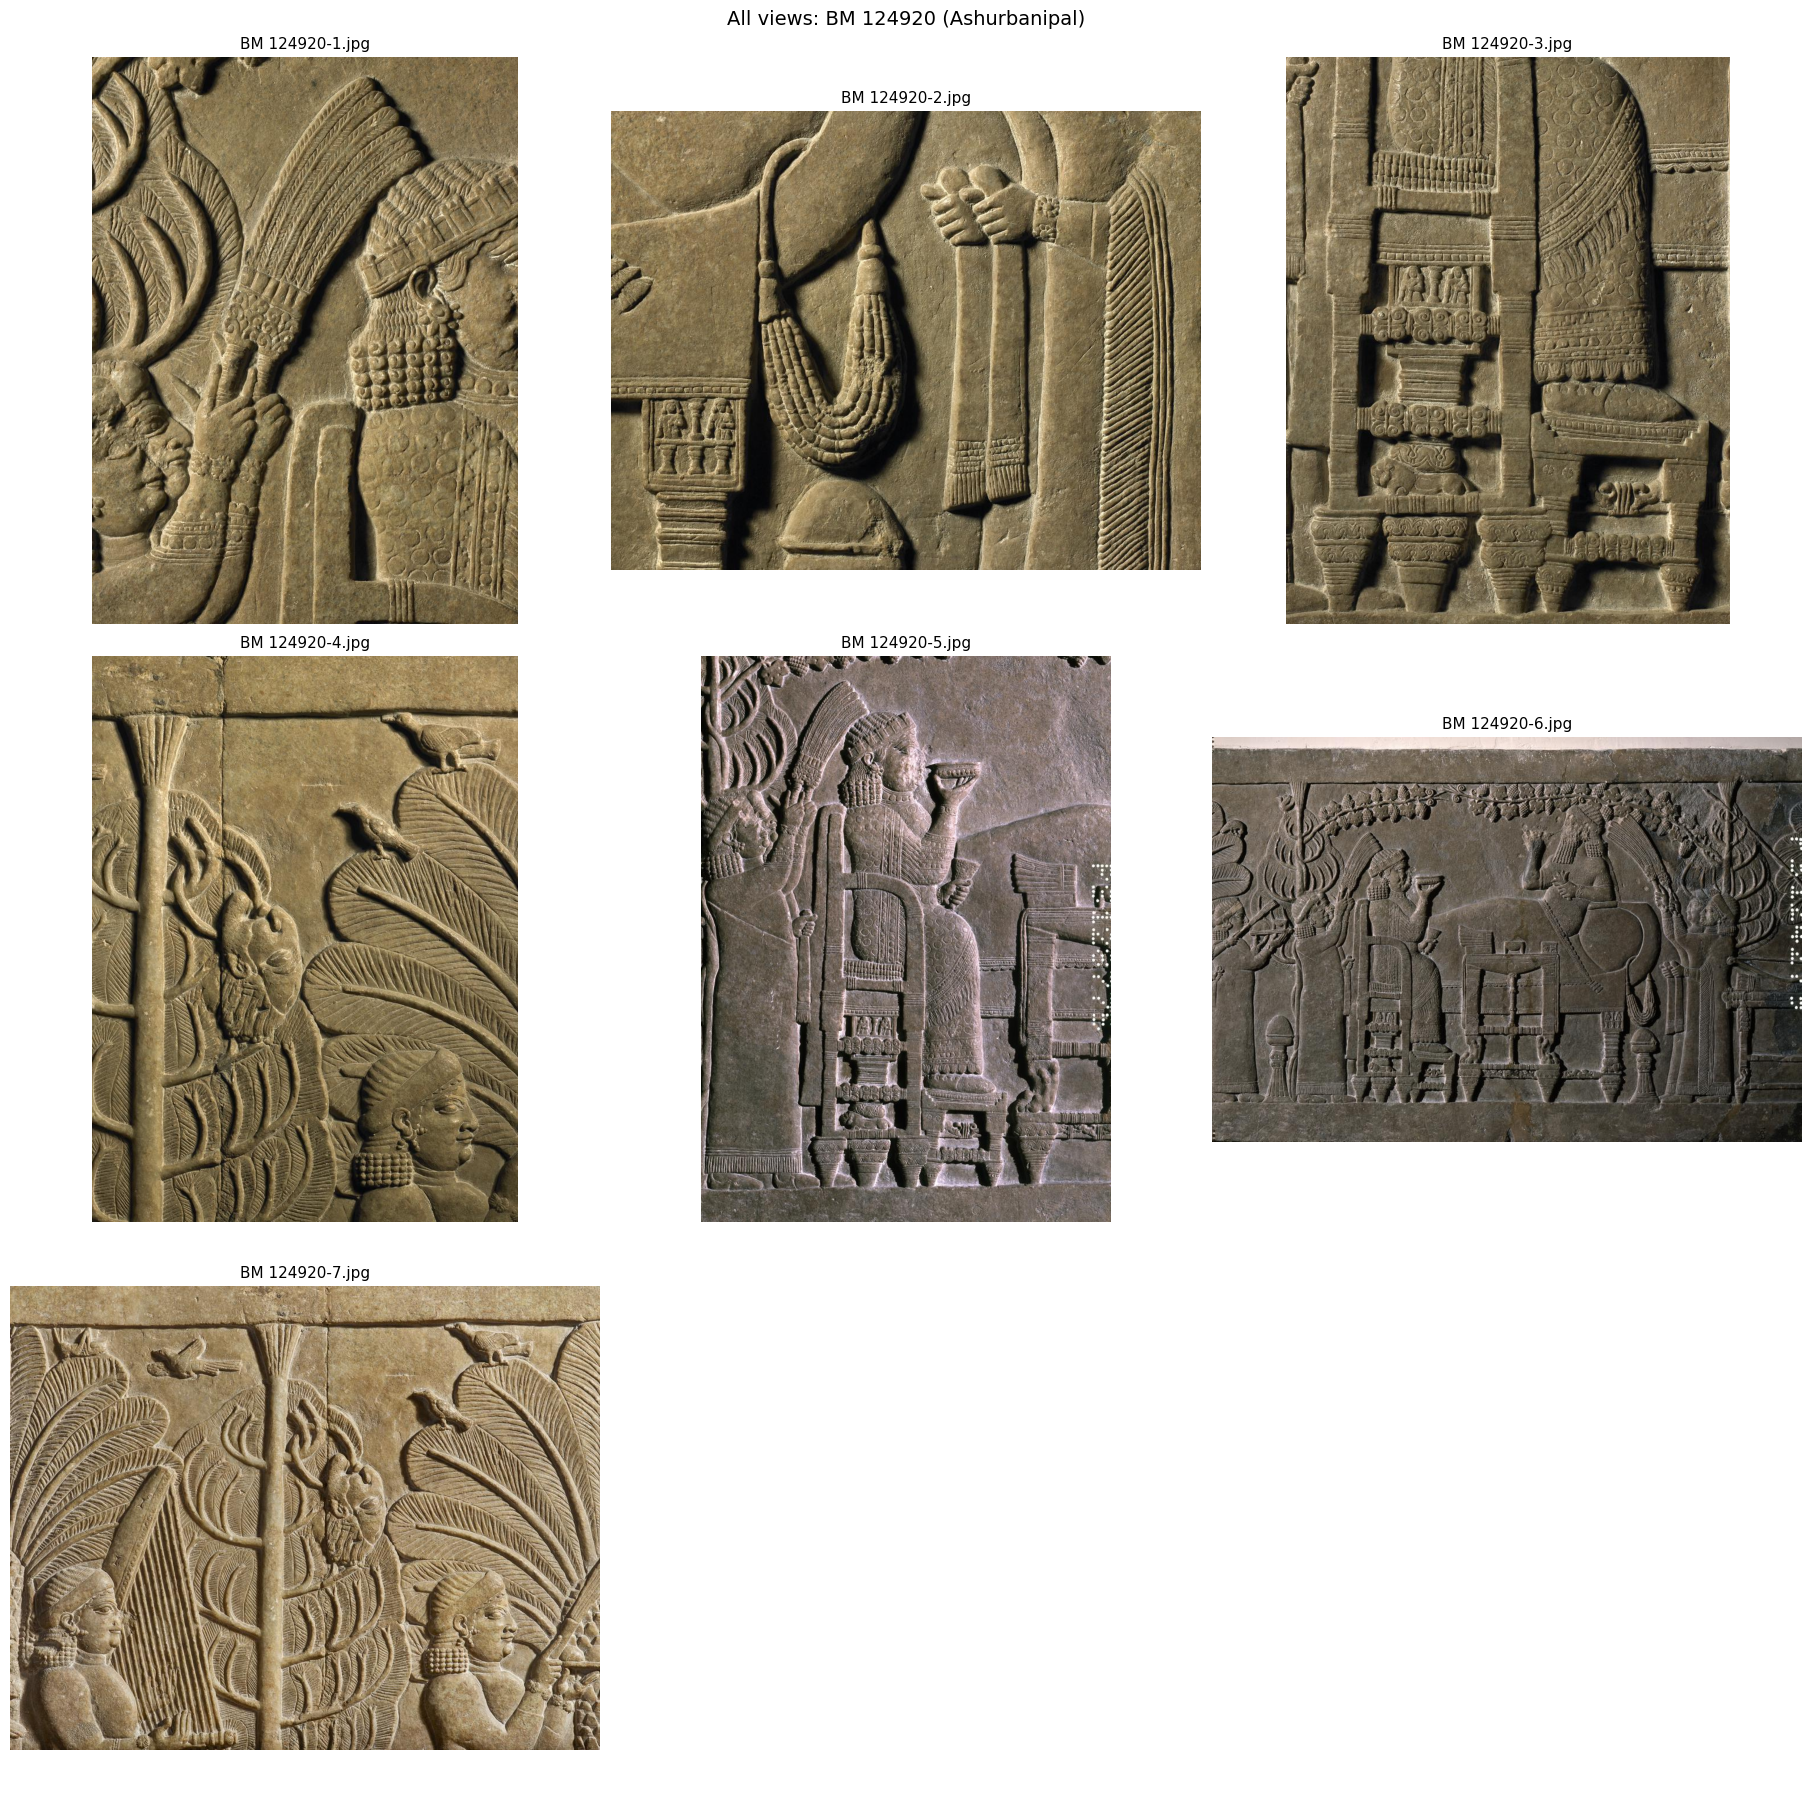

In [6]:
plot_relief_views(
    image_level_csv=IMAGE_LEVEL_CSV,
    image_root=IMAGE_ROOT,
    relief_id=query_relief_id,
    title=f"All views: {query_relief_id} ({query_authority})",
    show=True
);

# show all views of the top-1 retrieved relief

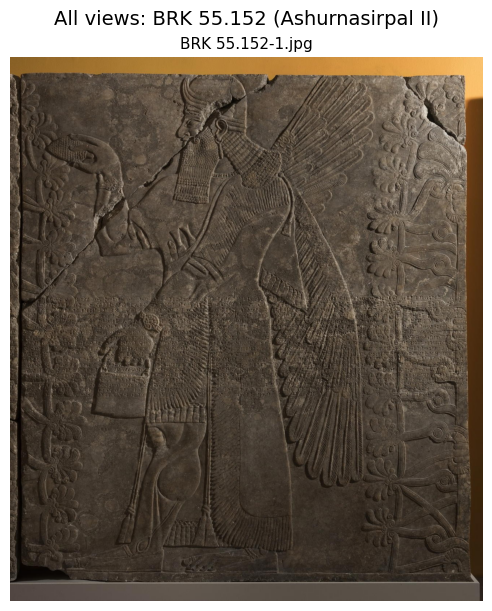

In [7]:
top1_relief_id = topk_reliefs[0]
top1_authority = topk_labels[0]

plot_relief_views(
    image_level_csv=IMAGE_LEVEL_CSV,
    image_root=IMAGE_ROOT,
    relief_id=top1_relief_id,
    title=f"All views: {top1_relief_id} ({top1_authority})",
);